# Medical Deep Learning / Computer Vision Project
### by Yassine Zanned

###This project implements the RAFT (Recurrent All-Pairs Field Transforms) model for estimating optical flow in medical imaging sequences. Optical flow can be valuable for analyzing motion in medical videos like ultrasound, endoscopy, or MRI time series.

## Here we'll go through each step and implement their corresponding code for this DL/CV project

## 1. Cloning the RAFT Github repository

---



In [1]:
!git clone "https://github.com/princeton-vl/RAFT.git"

Cloning into 'RAFT'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 147 (delta 0), reused 0 (delta 0), pack-reused 146 (from 2)
Receiving objects: 100% (147/147), 10.01 MiB | 19.10 MiB/s, done.
Resolving deltas: 100% (57/57), done.


## 2. Downloading pre-trained models (RAFT-things, kitti, sintel, chairs and small)

---

In [2]:
!./RAFT/download_models.sh
!rm -r /content/models.zip

--2025-04-01 15:01:13--  https://dl.dropboxusercontent.com/s/4j4z58wuv8o0mfz/models.zip
Resolving dl.dropboxusercontent.com (dl.dropboxusercontent.com)... 162.125.65.15, 2620:100:6021:15::a27d:410f
Connecting to dl.dropboxusercontent.com (dl.dropboxusercontent.com)|162.125.65.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81977417 (78M) [application/zip]
Saving to: ‘models.zip’

models.zip          100%[===================>]  78.18M  28.7MB/s    in 2.7s    

2025-04-01 15:01:17 (28.7 MB/s) - ‘models.zip’ saved [81977417/81977417]

Archive:  models.zip
   creating: models/
  inflating: models/raft-kitti.pth   
  inflating: models/raft-sintel.pth  
  inflating: models/raft-chairs.pth  
  inflating: models/raft-things.pth  
  inflating: models/raft-small.pth   


##3. Change the files raft.py, demo.py, evaluate.py and datasets.py with the ones that I modified to work on colab

In [3]:
%cd /content/
!git clone "https://github.com/GitY11Startler/raft-files.git"

!cp /content/raft-files/raft.py /content/RAFT/core/raft.py
!cp /content/raft-files/demo.py /content/RAFT/demo.py
!cp /content/raft-files/evaluate.py /content/RAFT/evaluate.py
!cp /content/raft-files/datasets.py /content/RAFT/core/datasets.py

/content
Cloning into 'raft-files'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 67 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 4.01 MiB | 14.76 MiB/s, done.
Resolving deltas: 100% (32/32), done.


---
##3.5. Also please make sure to change the runtime type from CPU to T4 GPU because the device type in the modified file raft.py has been set to CUDA(GPU) (RAFT has been trained on CUDA so it seems pretty conveient to pick GPU as the device type)


#**You can skip the demo, evaluation and training steps directly to step2 of the project**



##Here we run the demo.py file and look at the output optical flow in flow_output.png

---

/content/RAFT
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[ WARN:0@5.831] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png
Saved flow_output.png


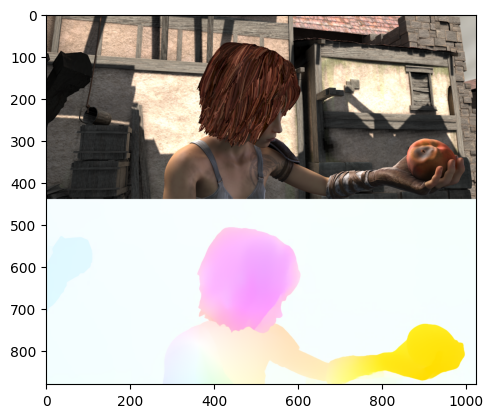

In [ ]:
%cd /content/RAFT/
# model_name = raft-sintel.pth
!python demo.py --model=/content/models/raft-sintel.pth --path=demo-frames

# Display the flow output image
import matplotlib.pyplot as plt
plt.imshow(plt.imread('/content/RAFT/flow_output.png'))

---
##Download the Sintel dataset for the evaluation step

In [ ]:
!mkdir -p /content/datasets/Sintel
!wget http://files.is.tue.mpg.de/sintel/MPI-Sintel-complete.zip -O sintel.zip
!unzip sintel.zip -d /content/datasets/Sintel
!rm sintel.zip

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/Sintel/training/invalid/ambush_2/frame_0016.png  
  inflating: /content/datasets/Sintel/training/invalid/ambush_2/frame_0011.png  
  inflating: /content/datasets/Sintel/training/invalid/ambush_2/frame_0007.png  
  inflating: /content/datasets/Sintel/training/invalid/ambush_2/frame_0009.png  
   creating: /content/datasets/Sintel/training/invalid/cave_2/
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0028.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0021.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0026.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0013.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0014.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0005.png  
  inflating: /content/datasets/Sintel/training/invalid/cave_2/frame_0002.png  
  inflati

##For instance, here we can evaluate raft-sintel on the Sintel dataset that we just downloaded

In [ ]:
%cd /content/RAFT/
!python evaluate.py --model=/content/models/raft-sintel.pth --dataset=sintel --mixed_precision

/content/RAFT
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Validation (clean) EPE: 0.764390, 1px: 0.923343, 3px: 0.968691, 5px: 0.979256
Validation (final) EPE: 1.216202, 1px: 0.886193, 3px: 0.946131, 5px: 0.962822


###Here is how to train the chosen model, however I didn't do this step since it won't contribute to the completion of the project's tasks.

In [ ]:
%cd /content/RAFT/
!./train_standard.sh

---
##Now let's get into work with the tasks that we're requested to do
---

## Step 2: Optical Flow Estimation between Two Rectified Stereo Images
###1. Write a Python script that takes two rectified stereo images as input. (You can use the images in the attachment)
###2. Use the RAFT model to estimate optical flow between the two images.
###3. Visualize and save the computed optical flow.
---

### I started by uploading the .zip file containing the two stereo images
---

In [4]:
# Download the entire repo as ZIP
!wget https://github.com/GitY11Startler/raft-files/archive/main.zip -O repo.zip

# Unzip ONLY the "DL Medical Assignment" folder
!unzip repo.zip "raft-files-main/DL Medical Assignment/*"

# Move the folder to /content/
!mv "raft-files-main/DL Medical Assignment" /content/

# Clean up
!rm -rf repo.zip raft-files-main

--2025-04-01 15:01:42--  https://github.com/GitY11Startler/raft-files/archive/main.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/GitY11Startler/raft-files/zip/refs/heads/main [following]
--2025-04-01 15:01:42--  https://codeload.github.com/GitY11Startler/raft-files/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.121.10
Connecting to codeload.github.com (codeload.github.com)|140.82.121.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘repo.zip’

repo.zip                [ <=>                ]   3.99M  --.-KB/s    in 0.1s    

2025-04-01 15:01:43 (34.2 MB/s) - ‘repo.zip’ saved [4184036]

Archive:  repo.zip
58688b11e6ce80409141867a2916e1175ae244e6
   creating: raft-files-main/DL Medical Assignment/
  inflating: raft-files-mai

---
### Because I wasn't able to make sure that the script finds the raft.py file to use its RAFT class as well as use the raft imports themselves (for instance this script can't find the updates.py file as well specified at the beginning of the raft.py file) I used the following script:

```
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from argparse import Namespace

# Link the current file to the core (needed to access the RAFT class in raft.py)
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(__file__), 'core'))

# Set up RAFT
def load_raft(model_path):
    args = Namespace(
        small=False,
        mixed_precision=False,
        alternate_corr=False
    )
    
    from raft import RAFT
    model = torch.nn.DataParallel(RAFT(args))
    # model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.load_state_dict(torch.load(model_path))
    return model

def preprocess_image(image):
    """Convert image to tensor and normalize"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = torch.from_numpy(image).permute(2, 0, 1).float()
    return image[None].to('cuda')

def compute_optical_flow(model, img1, img2):
    """Compute flow between two images"""
    with torch.no_grad():
        flow_low, flow_up = model(img1, img2, iters=20, test_mode=True)
    return flow_up[0].permute(1, 2, 0).cpu().numpy()

def visualize_flow(flow):
    """Convert flow to RGB visualization"""
    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 1] = 255
    
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Main execution
if __name__ == '__main__':
    # Load your stereo images (replace with your actual images)
    img1 = cv2.imread('/content/DL Medical Assignment/frame_left.png')
    img2 = cv2.imread('/content/DL Medical Assignment/frame_right.png')
    
    # Check if images loaded properly
    if img1 is None or img2 is None:
        raise ValueError("Could not load images! Check file paths")
    
    # Resize to same dimensions if needed
    if img1.shape != img2.shape:
        h, w = img1.shape[:2]
        img2 = cv2.resize(img2, (w, h))
    
    # Load RAFT model
    model = load_raft('/content/models/raft-sintel.pth').to('cuda')
    model.eval()
    
    # Preprocess images
    img1_tensor = preprocess_image(img1)
    img2_tensor = preprocess_image(img2)
    
    # Compute optical flow
    flow = compute_optical_flow(model, img1_tensor, img2_tensor)
    
    flow_img = visualize_flow(flow)
    
    # Save flow visualization
    cv2.imwrite('optical_flow.png', flow_img)
    print("Saved optical flow to optical_flow.png")
```

### I saved the above code in a file called step2.py in my Github repository which I then copied to the location /content/RAFT. Down below is the output of the resulting optical flow image
---

/content/RAFT
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Saved optical flow to optical_flow.png


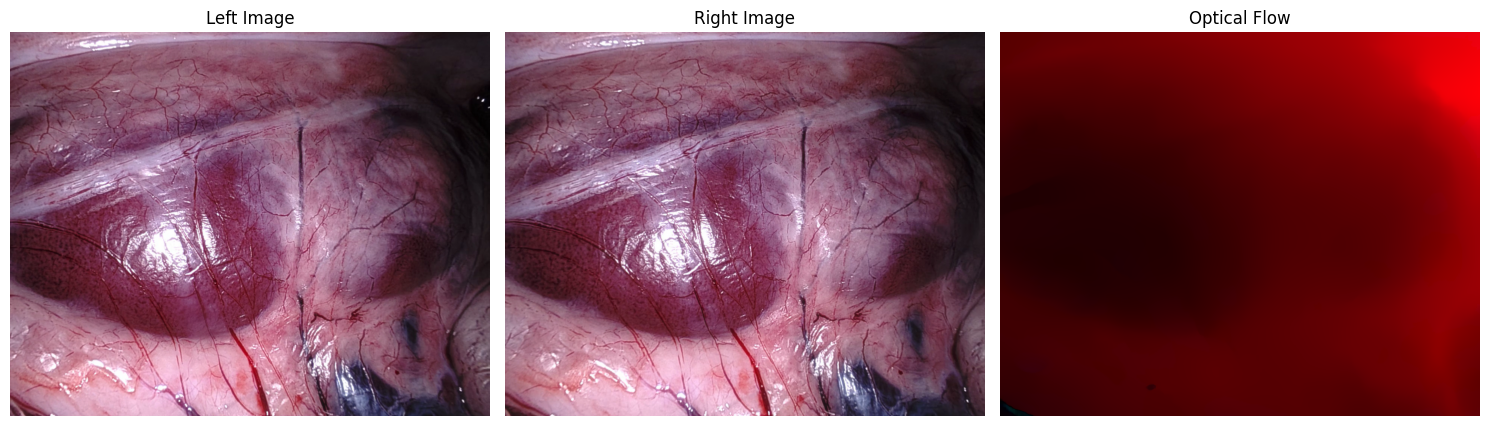

In [5]:
# First, copy the step2.py file from raft-files to /content/RAFT
!cp /content/raft-files/step2.py /content/RAFT/

# Run the file
%cd /content/RAFT
!python step2.py

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Left image
plt.subplot(1, 3, 1)
plt.imshow(plt.imread('/content/DL Medical Assignment/frame_left.png'))
plt.title("Left Image")
plt.axis('off')  # Hide axes for cleaner display

# Right image
plt.subplot(1, 3, 2)
plt.imshow(plt.imread('/content/DL Medical Assignment/frame_right.png'))
plt.title("Right Image")
plt.axis('off')

# Optical flow result
plt.subplot(1, 3, 3)
plt.imshow(plt.imread('/content/RAFT/optical_flow.png'))
plt.title("Optical Flow")
plt.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

###The optical flow shows the motion estimation between the left and right frames. This output is convenient since both stereo images are almost identical with a tiny shift to the right in the right frame.

---
## Step 3: Condition for Using Optical Flow as Disparity
###1. Explain in your report under what conditions the optical flow at a pixel can be used as a disparity value.


Optical flow can be used as disparity when:
*   Rectified stereo pairs: The images must be epipolar-aligned (horizontal displacement only)
*   Left-to-right flow: Flow vectors should be predominantly horizontal (x-direction)
*   No occlusion: Pixels visible in both images (no flow to/from occluded regions)
*   Forward motion: For dynamic scenes, camera motion should be mostly translational













###2. Implement a function that gives a mask for valid disparity values from the optical flow field based on what you suggested above.
---

```
def get_valid_disparity_mask(flow, max_vertical_threshold=0.5, min_horizontal_flow=1, max_horizontal_flow=50):
    """
    Creates a mask of pixels where optical flow can be used as disparity.
    
    Args:
        flow: Optical flow array (H,W,2) where flow[...,0]=x, flow[...,1]=y
        max_vertical_threshold: Maximum allowed vertical flow (pixels)
        min_horizontal_flow: Minimum required horizontal flow (pixels)
    
    Returns:
        Binary mask (H,W) where True indicates valid disparity
    """
    horizontal_flow = flow[..., 0]
    vertical_flow = flow[..., 1]
    
    # Conditions:
    # 1. Vertical flow near zero (rectified images)
    # 2. Horizontal flow sufficient (not noise)
    # 3. Positive horizontal flow (left-to-right convention)
    valid_mask = (
        (np.abs(vertical_flow) < max_vertical_threshold) &
        (horizontal_flow > min_horizontal_flow) &
        (horizontal_flow < max_horizontal_flow))
    
    return valid_mask   
```

###Here I specified three parameters in my get_masked_disparity function: max_vertical_threshold, min_horizontal_threshold and max_horizontal_threshold. I computed the min and max values of the horizontal flow values and found them to be equal to -7.7 and 54.1px respectively. I then tried using the respective default values of 1 and 54 because using negative values that are bigger than the min proved to have no significant impact on the masking output. Besides, I wanted to use those values by default to have a noticeable masking effect. I'll talk more about max_vertical_threshold just later in the step 3 results.

/content/RAFT
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Output saved to masked_output.png
Output saved to filtered_disparity.png


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

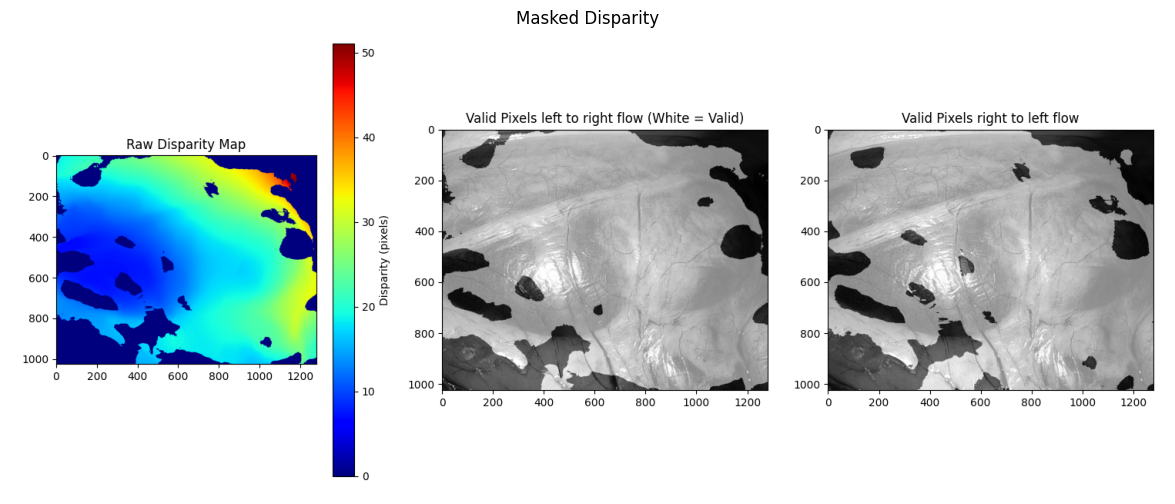

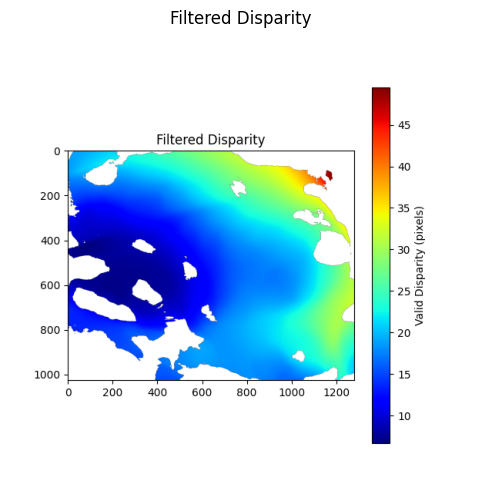

In [6]:
!cp /content/raft-files/step3.py /content/RAFT/

%cd /content/RAFT
!python step3.py

import matplotlib.pyplot as plt

# Optical flow result
plt.figure(figsize=(15, 6))
plt.imshow(plt.imread('masked_output.png'))
plt.title("Masked Disparity")
plt.axis('off')

# Optical flow result
plt.figure(figsize=(6, 6))
plt.imshow(plt.imread('filtered_disparity.png'))
plt.title("Filtered Disparity")
plt.axis('off')

###Here we used the approach of introducing a mask to both optical flows (left-to-right flow and right-to-left flow), compared those masks and applied a final filtering mask taking the intersection of both valid masks and applying it on the average of both flows disparities.

###On another sidenote, in step3.py we introduced two variables (eps1 and eps2) to study the evolution of both flows in a more limited range (in two ranges reduced by eps1 and ep2 for each flow direction, please note what I did in the step3.py for more understanding).

###With some empirical observations, I found that the best maximum vertical threshold value for both values approximates to 0.5, but of course it can be adjustable by modifying the variable max_v_thr.

##Step 4: Disparity-to-Depth Conversion
###1. Search for a formula that relates disparity and depth. Assume that the stereo setup is calibrated, and you are given the focal length and baseline. (For the images in the attachment find the camera calibration parameters in calib.txt)


###calib.txt gives us:

```
Left Camera Matrix:
[ 1.03530811e+03, 0., 5.96955017e+02,
  0., 1.03508765e+03, 5.20410034e+02,
  0., 0., 1. ]
  
Right Camera Matrix:
[ 1.03517419e+03, 0., 6.88361877e+02,
  0., 1.03497900e+03, 5.21070801e+02,
  0., 0., 1. ]

Stereo Baseline: 4.14339018e+00
```

###The two matrices are in the following shape:
$$
K = \begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
$$



###We can deduce that focal points are:  
$$f_x^{left} = 1035.30811, f_x^{right} = 1035.17419$$

###And the principal points are:
$$c_x^{left} = 596.955017, c_x^{right} = 688.361877$$

###So the disparity is calculated as such:
$$d = x_{left} - x_{right}$$

###Since both cameras have different principal components, the disparity needs to be adjusted:
$$d = (x_{left} - x_{right}) - (c_x^{left} - c_x^{right})$$

###So,
$$d_{corrected} = d - Δc_x$$
###where
$$Δc_x = c_x^{left} - c_x^{right} = -91.40686$$

###Thus,
$$d_{corrected} = d + 91.40686$$

###Here's the formula for the disparity-to-depth conversion:
$$depth = \frac{f_x . B}{d_{corrected}}$$

###where B is the stereo baseline found at the bottom of calib.txt:
$$B = 4.14339018$$


###2. Implement a function that takes a disparity map as input and returns a depth map using the derived formula

```
def disparity_to_depth(fx, B, cx_left, cx_right, disparity):
    """Compute depth from disparity, applying principal point offset correction"""
    delta_cx = cx_left - cx_right  # Principal offset
    disparity_corrected = disparity - delta_cx  # Corrected disparity
    
    # Avoid division by zero (set small values to a minimum disparity)
    disparity_corrected = np.maximum(disparity_corrected, 1e-6)

    # Compute depth
    depth = (fx * B) / disparity_corrected
    return depth
```

/content/RAFT
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Output saved to depth_maps.png


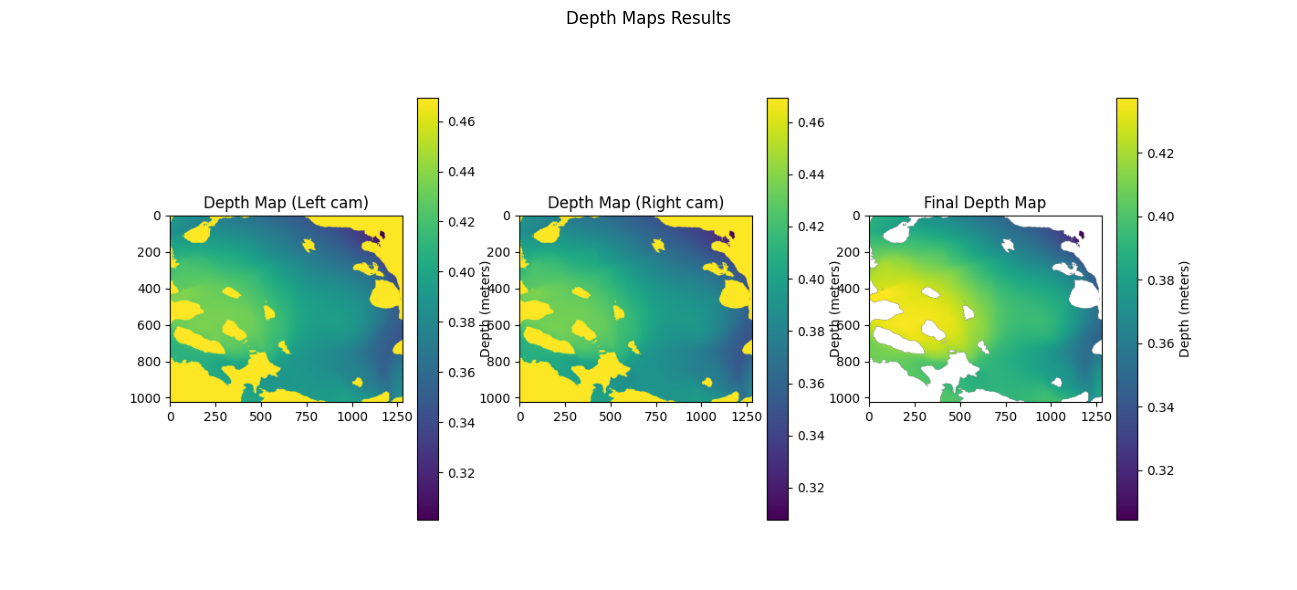

In [7]:
!cp /content/raft-files/step4.py /content/RAFT/

%cd /content/RAFT
!python step4.py

# Optical flow result
plt.figure(figsize=(14, 6))
plt.imshow(plt.imread('depth_maps.png'))
plt.title("Depth Maps Results")
plt.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

###This returns three maps: Depth Map (Left cam) using the left camera focal length, Depth Map (Right cam) using the right camera's and Final Depth Map averaging both focal lengths and using the filtered disparity displayed in step 3.

##Other observations from the project & encountered challenges:
To ensure the RAFT model runs smoothly on Google Colab, several adjustments were necessary:

* Runtime Change: Switched from CPU to T4 GPU for compatibility with the RAFT model requirements.

* RAFT Model Fixes: Modified raft.py by explicitly specifying 'cuda' for torch.amp.autocast (Lines 99, 110, and 127).

* Image Display Fix: Replaced cv2.imshow with cv2.imwrite('flow_output.png', img_flo[:, :, [2,1,0]]) in demo.py, ensuring outputs are saved correctly.

* Optical flow output is stored in flow_output.png.

Performance Across RAFT Models:
* RAFT-Sintel & RAFT-Things: Produced refined contours, closely resembling the original images.

* RAFT-Chairs: Showed yellow outliers near object edges, indicating less refined flow estimation.

* RAFT-Kitti: Contours were less refined, with excessive background filling, especially on the lower side of objects.

* RAFT-Small: Encountered size mismatch errors, preventing direct execution without further modifications.

## Conclusion

In this project, we successfully implemented the RAFT model for optical flow estimation in medical imaging sequences. We explored how to set up the model, process a pair of stereo images, and generate disparity-to-depth maps.

Key takeaways:
- RAFT provides highly accurate optical flow estimation, which is valuable for tracking motion in medical imaging.
- The model performs well, but further improvements could involve fine-tuning RAFT on medical datasets for better accuracy.